In [45]:
# from lakeshore import Model240, Model240InputParameter, Model240CurveHeader
import pynanovna
from pynanovna.utils import stream_from_csv
from pynanovna.vis import plot, polar
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import warnings
import time
import datetime
import os
from scipy.optimize import curve_fit
import warnings
import requests
import json
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, plot_errbar, big_plt_font
big_plt_font()
# warnings.filterwarnings('once')

import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
import pandas as pd

big_plt_font()
rm = visa.ResourceManager()
## uncomment the following if full address not known
instruments = rm.list_resources() 
usb = list(filter(lambda x: 'USB' in x, instruments))
print(usb)
SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')

# SSA = rm.open_resource(usb[1])
print(SSA.query("*IDN?"))

['ASRL/dev/ttyUSB0::INSTR', 'USB0::6833::3601::DP8B260200018::0::INSTR', 'USB0::2391::7175::MY53200916::0::INSTR', 'USB0::6833::3601::DP8L251900013::0::INSTR']
Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10



In [46]:
def S21(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (Q/Qc)/(1+2*1j*Q*(f-f0)/f0)

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def S11(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (1 - 2*(Q/Qc)/(1+2*1j*Q*(f-f0)/f0))

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def vec_S21(S21_concat):
    l = int(len(S21_concat)/2)
    r = S21_concat[:l]
    i = S21_concat[l:]
    return [r,i]

def vec_S11(S11_concat):
    l = int(len(S11_concat)/2)
    r = S11_concat[:l]
    i = S11_concat[l:]
    return [r,i]

def mag_S21(re_s21, im_s21):
    return (np.sqrt(re_s21**2+im_s21**2))

def phase_S21(re_s21, im_s21):
    return np.arctan(im_s21/re_s21)

def get_Qi(Q, Qc):
    return 1 / (1/Q - 1/Qc)

def fit_S21(s2p_file, pi = [270e6,500,1000,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])

  freqs_np = np.array(df.freq)
  ReS21 = np.array(df['S21']).astype(complex).real
  ImS21 = np.array(df['S21']).astype(complex).imag

  magS21 = np.sqrt(ReS21**2+ImS21**2)

  

  max_freq = (freqs_np[np.where(magS21==np.max(magS21))])

  start = 250e6  #max_freq[0]-3e6
  stop= 300e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS21_np = np.array(ReS21)[min_index:max_index]
  imS21_np = np.array(ImS21)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S21_data = np.concatenate((reS21_np,imS21_np))

  params, pcov = curve_fit(S21, freqs, S21_data,p0=pi)

  S21_Concat = S21(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  S21_Vec = vec_S21(S21_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S21_mags = np.sqrt(S21_Vec[0]**2+S21_Vec[1]**2)

  plt.plot(freqs/1e6,S21_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S21)')
  plt.legend()

  
  return params

def fit_S11(s2p_file, pi = [227e6,200,100,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  #df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])
  df = pd.read_csv(filepath)

  freqs_np = np.array(df['freq'], dtype=np.float64)
  ReS11 = np.array(df['S11'], dtype=np.complex128).real
  ImS11 = np.array(df['S11'], dtype=np.complex128).imag

  print(np.shape(ReS11))

  magS11 = np.sqrt(ReS11**2+ImS11**2)

  

  max_freq = (freqs_np[np.where(magS11==np.max(magS11))])

  start = 210e6  #max_freq[0]-3e6
  stop= 250e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS11_np = np.array(ReS11)[min_index:max_index]
  imS11_np = np.array(ImS11)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S11_data = np.concatenate((reS11_np,imS11_np))

  params, pcov = curve_fit(S11, freqs, S11_data,p0=pi)

  S11_Concat = S11(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  #S11_Concat = S11(freqs,pi[0],pi[1],pi[2],0,0)#,params[3],params[4])
  S11_Vec = vec_S11(S11_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S11_mags = np.sqrt(S11_Vec[0]**2+S11_Vec[1]**2)

  plt.plot(freqs/1e6,S11_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.plot(freqs/1e6, magS11[min_index:max_index])
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S11)')
  plt.legend()
  return params

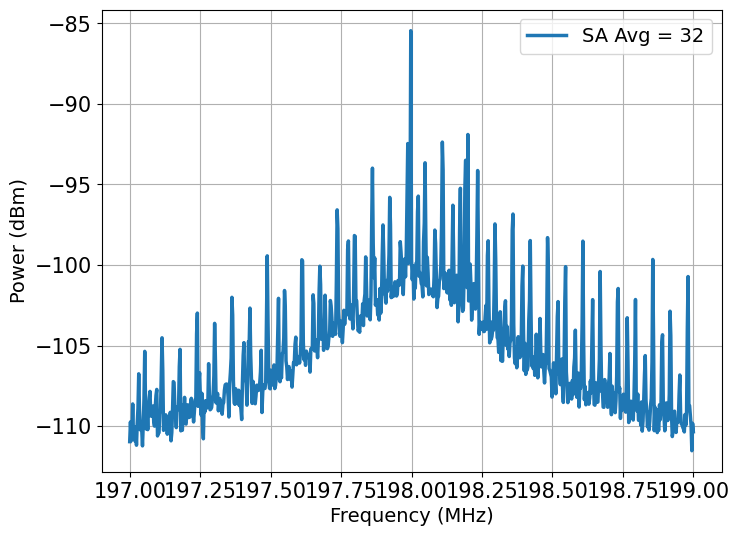

In [51]:
freq_center = 198 # MHz
freq_span = 2 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 10 
RBW = 1 #kHz
VBW = 1 #kHz
SWT = 1 #ms
N_AVG = 32

# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

# Set averaging ON and number of averages = 100
# SSA.write(":AVERage:TRACe1:COUNt 1")
SSA.write(f":AVERage:TRACe1:COUNt {N_AVG}")
SSA.write(f":TRACe1:MODE AVERage")
time.sleep(SWT*1e-3*N_AVG)

# Set power unit to dBm
SSA.write("UNIT:POW DBM")
SSA.write(":AVERage:TRAC1:CLEar")
while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
    continue
data_str_C = SSA.query(":TRACe1:DATA?")
data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
# Number of points in the trace
num_points = len(data_arr_C)

# Generate frequency axis in MHz
freq_start = freq_center - freq_span / 2
freq_stop  = freq_center + freq_span / 2
freq_axis = np.linspace(freq_start, freq_stop, num_points)

# --- Plot ---
plt.figure(figsize=(8,6))
# plot(freq_axis, data_arr_C, label="Avg = 1")
# plot(freq_axis, data_arr_B, label="Average = 1")
# plot(freq_axis, 10*np.log10(data_arr_C), label="PC Avg = 100")
plot(freq_axis, data_arr_C, label="SA Avg = 32")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.grid(True)
plt.legend()
plt.show()

data = {'freq': freq_axis, 'pow':data_arr_C}
df = pd.DataFrame(data)

filename = 'test.csv'
# df.to_csv(filename)

In [20]:
def take_vna_sweep(filename, folder_path): 
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path,filename)
    SSA.write(":AVERage:TRAC1:CLEar")
    while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
        continue
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    # Number of points in the trace
    num_points = len(data_arr_C)
    
    # Generate frequency axis in MHz
    freq_start = freq_center - freq_span / 2
    freq_stop  = freq_center + freq_span / 2
    freq_axis = np.linspace(freq_start, freq_stop, num_points)
    np.savez(file_path, freq=freq_axis, data=data_arr_C)
    return data_arr_C, freq_axis

In [21]:
def query_temp(stage, T_to_channels = {'40K': 1, '4K': 2, '0.4K': 5}): 
    req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
    data = req.json()
    ch = T_to_channels[stage]
    while data['channel_nr'] != ch: 
        req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
        data = req.json()
    return data['temperature']

In [22]:
base = r'/home/electron/data/cooldown_06012026/resonator'
os.makedirs(base, exist_ok=True)

In [48]:
filename = 'E.csv'
folder_path = base
data, freq = take_vna_sweep(filename, folder_path)

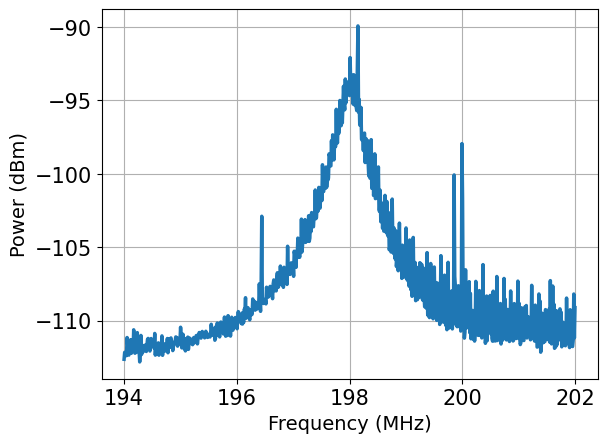

In [49]:
plot(freq, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')
plt.show()

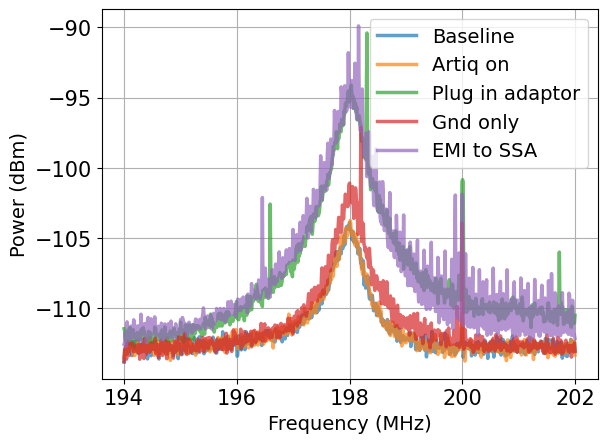

In [43]:
all_plots = ['all-noise-off-baseline', 'Artiq_on', 'Plug_adaptor', 'Gnd_only', 'EMI_SSA']
labels = ['Baseline', 'Artiq on', 'Plug in adaptor', 'Gnd only', 'EMI to SSA']

for i in range(len(all_plots)):
    plots = all_plots[i] 
    label = labels[i]
    data = np.load(f'{folder_path}/{plots}.csv.npz') 
    plot(data['freq'], data['data'], alpha=0.7, xlabel='Frequency (MHz)',
         ylabel='Power (dBm)', label=label)

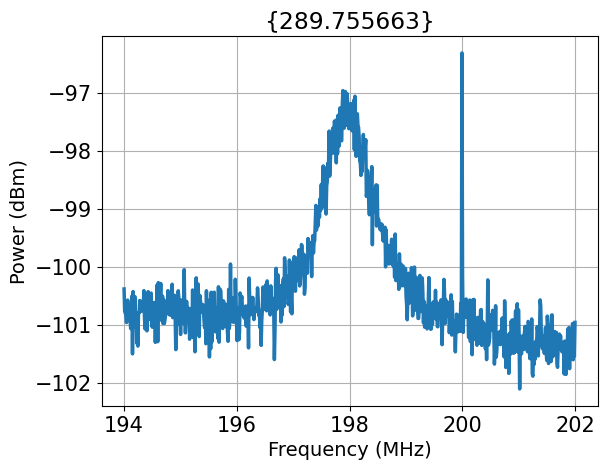

>>> Serial exception caught, sleep for 1s and continuing


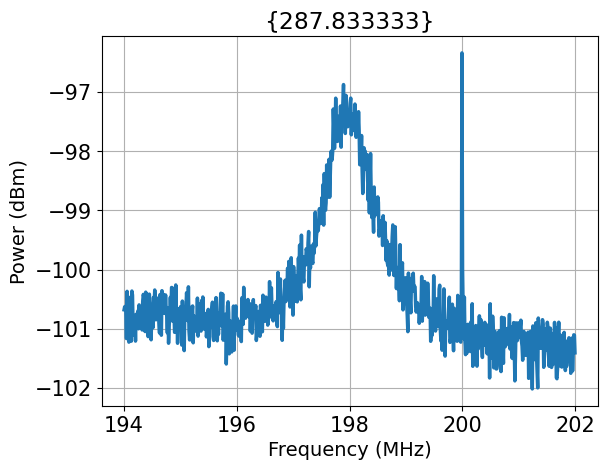

>>> Serial exception caught, sleep for 1s and continuing


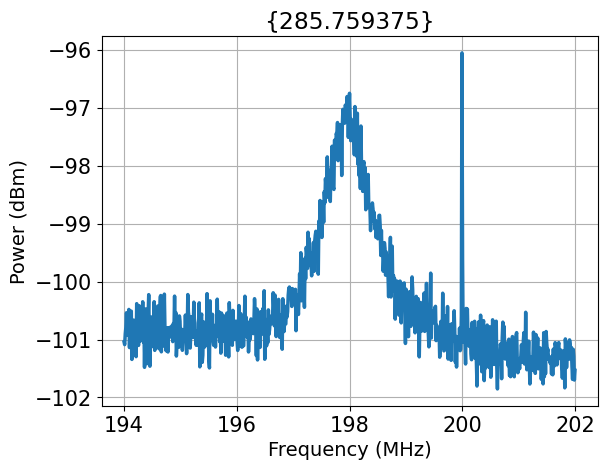

>>> Serial exception caught, sleep for 1s and continuing


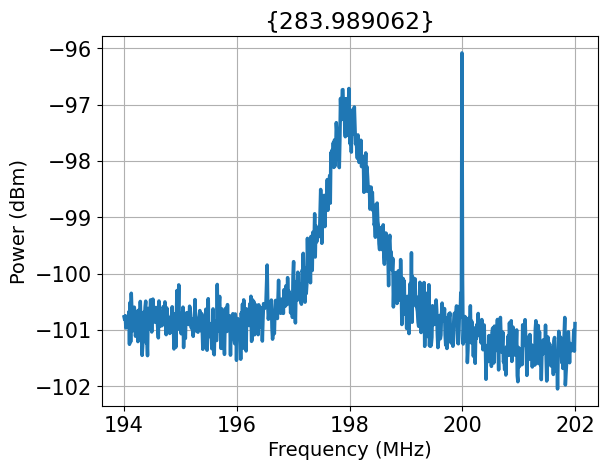

>>> Serial exception caught, sleep for 1s and continuing


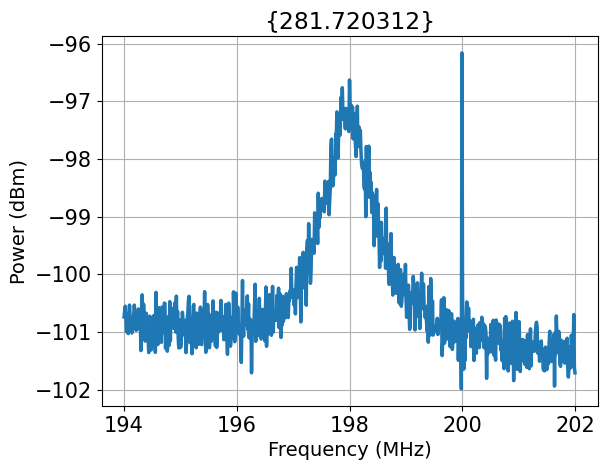

>>> Serial exception caught, sleep for 1s and continuing


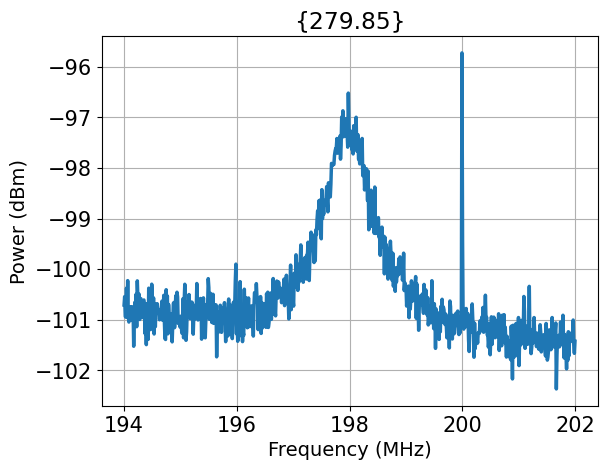

>>> Serial exception caught, sleep for 1s and continuing


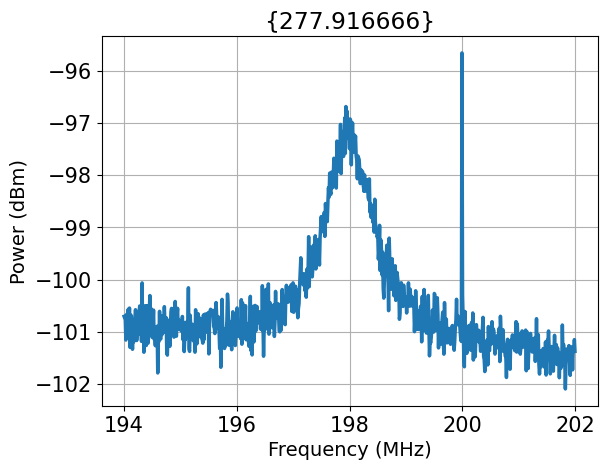

>>> Serial exception caught, sleep for 1s and continuing


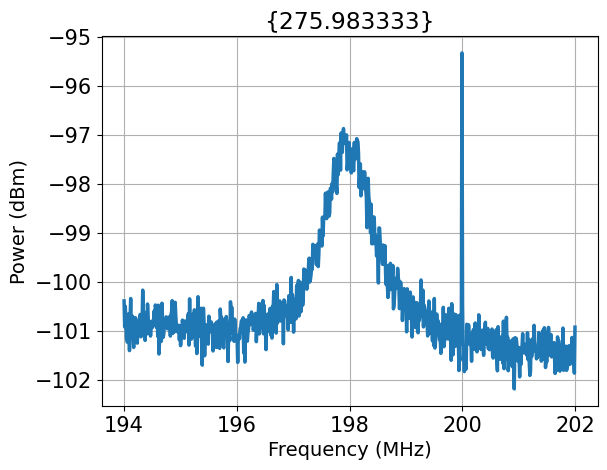

>>> Serial exception caught, sleep for 1s and continuing


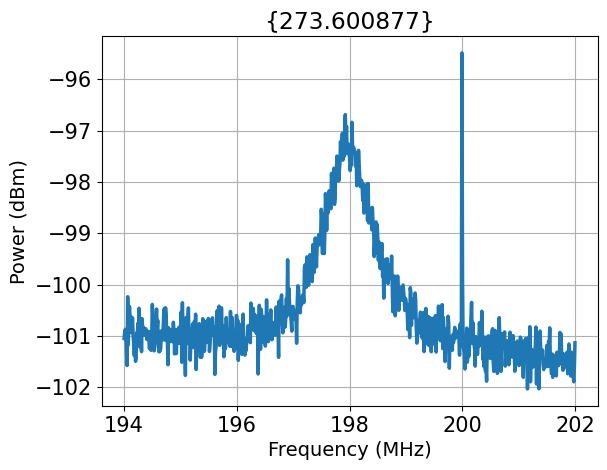

>>> Serial exception caught, sleep for 1s and continuing


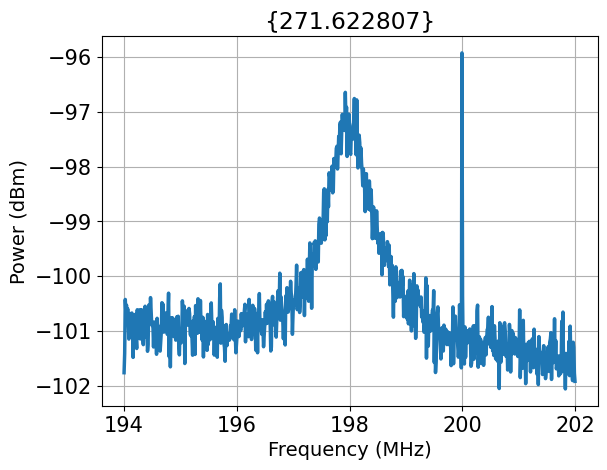

>>> Serial exception caught, sleep for 1s and continuing


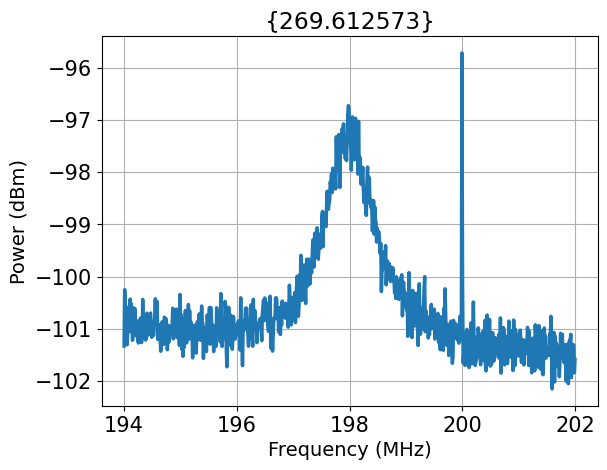

>>> Serial exception caught, sleep for 1s and continuing


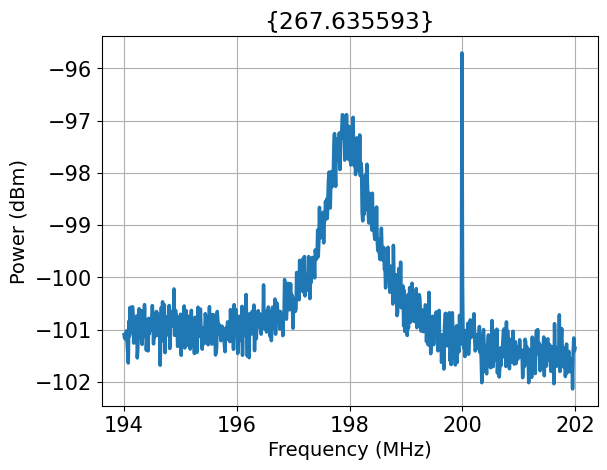

>>> Serial exception caught, sleep for 1s and continuing


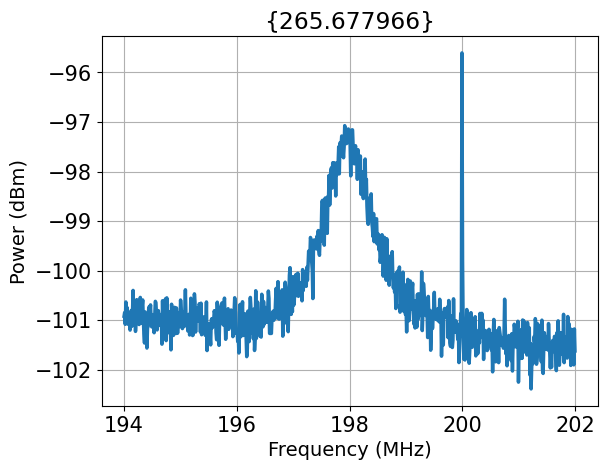

>>> Serial exception caught, sleep for 1s and continuing


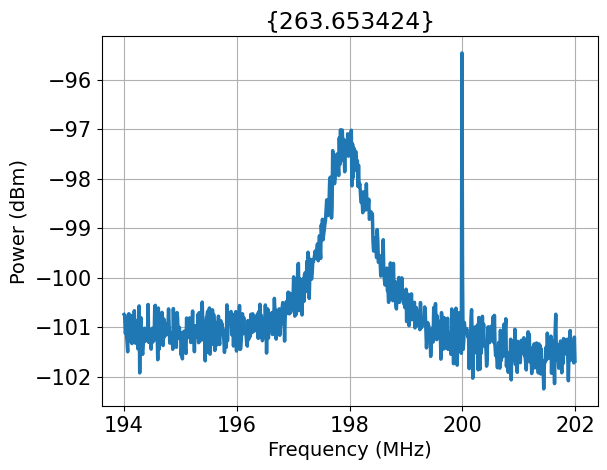

>>> Serial exception caught, sleep for 1s and continuing


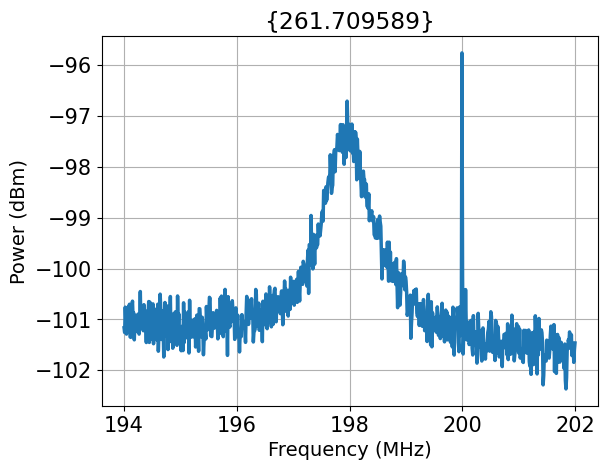

>>> Serial exception caught, sleep for 1s and continuing


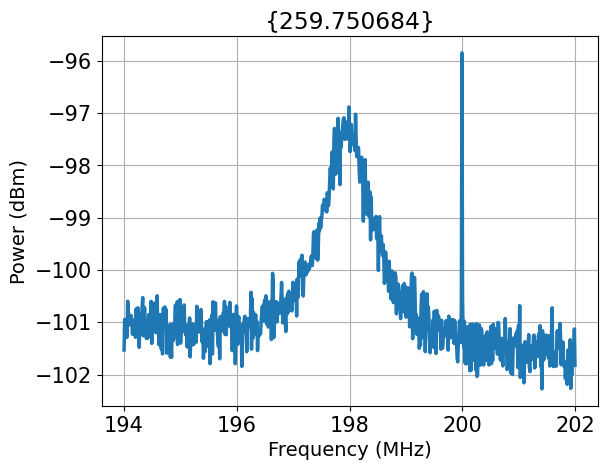

>>> Serial exception caught, sleep for 1s and continuing


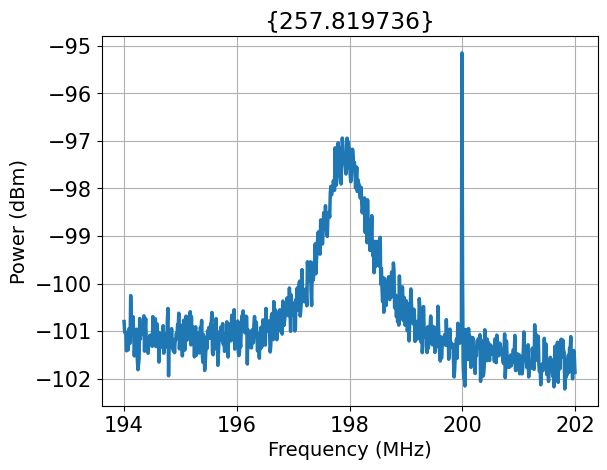

>>> Serial exception caught, sleep for 1s and continuing


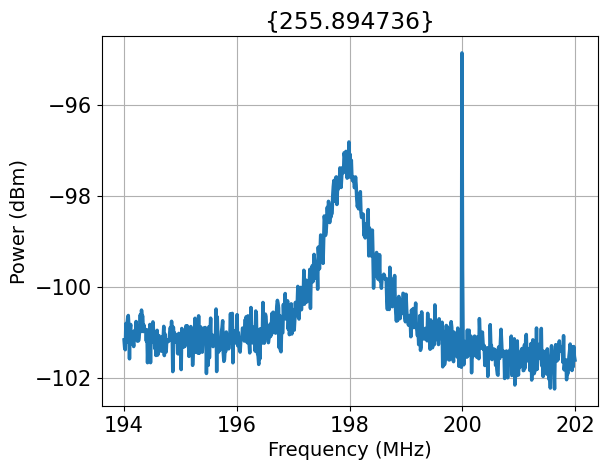

>>> Serial exception caught, sleep for 1s and continuing


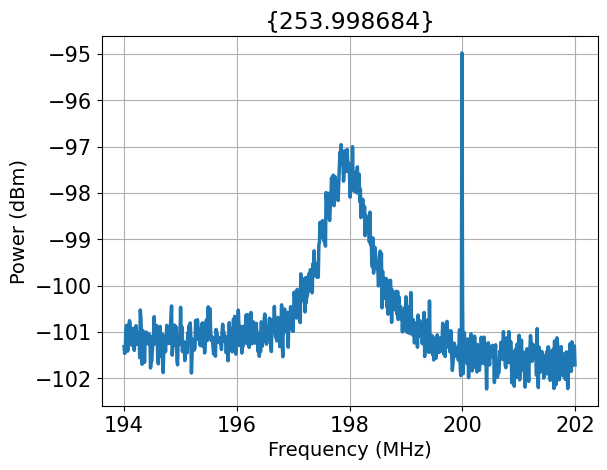

>>> Serial exception caught, sleep for 1s and continuing
>>> Temperature cannot reach the desired 252K limit in 100 queries, current temperature 252.49K


In [9]:
folder_path = base #+ r'warmup_02192026_trap'
os.makedirs(folder_path, exist_ok=True)
temp_list = list(range(290,4,-2))
query_period = 15 # s 
timeout_0 = 100 # N x query period

timeout = timeout_0
curr_T_i = 0 
while curr_T_i < len(temp_list) and timeout > 0: 
    curr_T = query_temp("0.4K") 
    if curr_T <= temp_list[curr_T_i]: 
        filename = f'{curr_T}'
        try:
            data, freq = take_vna_sweep(filename, folder_path)
            plot(freq, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)', title={curr_T})
            plt.show()
            curr_T_i += 1 
            timeout = timeout_0address
        except: 
            print(">>> Serial exception caught, sleep for 1s and continuing")
            time.sleep(1)
    else: 
        time.sleep(query_period) 
        timeout -= 1
        if timeout == 0: 
            print(f">>> Temperature cannot reach the desired {temp_list[curr_T_i]}K limit in {timeout_0} queries, current temperature {curr_T:.2f}K")